In [35]:
# ── Imports & Config ──────────────────────────────────────────────
import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'   # fallback for MPS-unsupported ops

import datetime, time, functools, warnings
import numpy as np
import pandas as pd
import polars as pl
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
import pyro.infer.autoguide as autoguide
from pyro.optim import Adam
from functools import partial
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from pybaseballstats.statcast import pitch_by_pitch_data
from pybaseballstats.utils.retrosheet_utils import _get_people_data

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
pyro.set_rng_seed(42)
print(f'Device: {device}')

TRAIN_YEARS   = [2021, 2022, 2023, 2024]
TEST_YEAR     = 2025
PRED_YEAR     = 2026
CURRENT_YEAR  = PRED_YEAR
MIN_PA_TRAIN  = 100
MIN_PA_PRED   = 20
SHRINK_N0     = 50      # prior mass in denominator units
PRIOR_DECAY   = 0.5     # exp decay per season back from most recent training year
                        # 2024=1.0, 2023=0.5, 2022=0.25, 2021=0.125

# ── NPS weights ────────────────────────────────────────────────────
# W_HR: HR(3) + R always scored(0.75) + avg RBI(1.582 × 0.75 = 1.19) = 4.94
#   source: 2021-2025 statcast, avg 1.582 RBI/HR (57.6% solo, 28.9% 2-run, etc.)
# W_BB: BB(1.0) + expected R from runner eventually scoring (~30% × 0.75 = 0.23) = 1.23
# W_K:  K(-0.5) direct; no secondary scoring effect
W_HR   = 4.94
W_BB   = 1.23
W_K    = 0.50

RISK_ALPHA    = 0.5   # risk-adjustment: score = mean - alpha * std

CACHE_DIR = os.path.join(os.path.dirname(os.path.abspath('')), 'waiver-tools', 'data')
os.makedirs(CACHE_DIR, exist_ok=True)

Device: mps


In [36]:
# ── Data Fetching ─────────────────────────────────────────────────
INCREMENTAL_LOOKBACK_DAYS = 3   # re-pull last N days to catch late-reported pitches


def _fetch_range(yr: int, start: str, end: str) -> pd.DataFrame:
    """Fetch pitch-by-pitch data between two dates using monthly chunks."""
    start_d = datetime.date.fromisoformat(start)
    end_d   = datetime.date.fromisoformat(end)

    month_starts = []
    d = start_d.replace(day=1)
    while d <= end_d:
        month_starts.append(d)
        d = (d.replace(day=28) + datetime.timedelta(days=4)).replace(day=1)

    chunks = []
    for ms in month_starts:
        next_m = (ms.replace(day=28) + datetime.timedelta(days=4)).replace(day=1)
        me = next_m - datetime.timedelta(days=1)
        chunk_start = max(ms, start_d).isoformat()
        chunk_end   = min(me, end_d).isoformat()

        for attempt in range(1, 4):
            try:
                result = pitch_by_pitch_data(
                    start_date=chunk_start,
                    end_date=chunk_end,
                    force_collect=True
                )
                if result is not None:
                    df = result.to_pandas()
                    for col in df.select_dtypes('object').columns:
                        non_null = df[col].dropna()
                        if len(non_null) > 0:
                            n_num = pd.to_numeric(non_null, errors='coerce').notna().sum()
                            if n_num / len(non_null) >= 0.5:
                                df[col] = pd.to_numeric(df[col], errors='coerce')
                    chunks.append(df)
                break
            except Exception as e:
                if attempt < 3:
                    print(f'  [{yr} {chunk_start}] attempt {attempt} failed: {e}; retrying...')
                    time.sleep(10 * attempt)
                else:
                    print(f'  [{yr} {chunk_start}] all retries failed, skipping.')

    return pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()


def _fetch_year(yr: int) -> pd.DataFrame:
    """
    Load one season of statcast data with smart caching:
      - Past seasons:    cache once forever (completed, immutable).
      - Current season:  use cache if < 24 h old; otherwise do an incremental
                         append — only fetch from (last cached date − lookback)
                         forward, avoiding a full-season re-pull every day.
    """
    cache = os.path.join(CACHE_DIR, f'statcast_{yr}.parquet')
    is_current = (yr == CURRENT_YEAR)
    today = datetime.date.today()

    # ── past seasons ──────────────────────────────────────────────
    if not is_current:
        if os.path.exists(cache):
            return pd.read_parquet(cache)
        print(f'  {yr}: fetching full past season...')
        df = _fetch_range(yr, f'{yr}-03-01', f'{yr}-10-31')
        df.to_parquet(cache, index=False)
        print(f'  {yr}: cached ({len(df):,} pitches)')
        return df

    # ── current season ────────────────────────────────────────────
    if os.path.exists(cache):
        age_s = (datetime.datetime.now() -
                 datetime.datetime.fromtimestamp(os.path.getmtime(cache))).total_seconds()
        if age_s < 86400:
            print(f'  {yr}: loaded from cache (< 24 h old)')
            return pd.read_parquet(cache)

        # incremental: fetch only the tail, then concat
        existing  = pd.read_parquet(cache)
        last_date = pd.to_datetime(existing['game_date']).dt.date.max()
        fetch_from = last_date - datetime.timedelta(days=INCREMENTAL_LOOKBACK_DAYS)
        print(f'  {yr}: cache stale — incremental fetch {fetch_from} → {today}')

        delta = _fetch_range(yr, fetch_from.isoformat(), today.isoformat())
        if not delta.empty:
            # drop the lookback window from cache to avoid duplicates, then append
            keep = pd.to_datetime(existing['game_date']).dt.date < fetch_from
            df = pd.concat([existing[keep], delta], ignore_index=True)
        else:
            df = existing
    else:
        # first run of the current season
        print(f'  {yr}: no cache — fetching season so far ({yr}-03-01 → {today})')
        df = _fetch_range(yr, f'{yr}-03-01', today.isoformat())

    df.to_parquet(cache, index=False)
    print(f'  {yr}: cache updated through {today} ({len(df):,} pitches total)')
    return df

In [ ]:
# ── Feature Computation ───────────────────────────────────────────
SWING_DESCS = frozenset([
    'swinging_strike', 'swinging_strike_blocked',
    'foul', 'foul_tip', 'foul_bunt', 'missed_bunt',
    'hit_into_play', 'hit_into_play_no_out', 'hit_into_play_score',
])
WHIFF_DESCS = frozenset(['swinging_strike', 'swinging_strike_blocked', 'missed_bunt'])
OUT_ZONE    = frozenset([11, 12, 13, 14])

# Statcast records launch_speed for both fair balls AND fouls (HawkEye tracks all batted balls).
# Hard-hit% and sweet-spot% must be computed on fair balls only — fouls rarely reach
# 95 mph and would otherwise cut every player's true rate roughly in half.
FAIR_DESCS  = frozenset(['hit_into_play', 'hit_into_play_no_out', 'hit_into_play_score'])

K_EVENTS  = frozenset(['strikeout', 'strikeout_double_play'])
BB_EVENTS = frozenset(['walk', 'intent_walk'])
PA_EVENTS = frozenset([
    'single', 'double', 'triple', 'home_run',
    'walk', 'intent_walk', 'hit_by_pitch',
    'strikeout', 'strikeout_double_play',
    'field_out', 'grounded_into_double_play', 'double_play',
    'force_out', 'fielders_choice', 'fielders_choice_out',
    'field_error', 'sac_fly', 'sac_bunt',
    'sac_fly_double_play', 'triple_play', 'catcher_interf',
])

# Maps each rate feature to its true denominator column (for principled shrinkage)
FEAT_DENOM = {
    'whiff_pct':      'swings',
    'chase_pct':      'out_zone',
    'hard_hit_pct':   'in_play',
    'sweet_spot_pct': 'in_play',
}

# Players absent from the Chadwick registry used by pybaseballstats
MANUAL_ID_TO_NAME = {
    608070: "José Ramírez",
    608324: "Alex Bregman",
    621493: "Taylor Ward",
    624413: "Pete Alonso",
    665742: "Juan Soto",
    666182: "Bo Bichette",
    686948: "Drake Baldwin",
    691777: "Max Muncy",
    691781: "Brady House",
    695578: "James Wood",
    695657: "Colson Montgomery",
    695734: "Daylen Lile",
    701350: "Roman Anthony",
    701398: "Sal Stewart",
    802139: "JJ Wetherholt",
    805300: "Jakob Marsee",
    805808: "Kevin McGonigle",
    808959: "Munetaka Murakami",
    679529: "Spencer Torkelson",
    800050: "Chase DeLauter",
    683357: 'Owen Caissie',
}


def compute_season_features(raw: pd.DataFrame, yr: int, min_pa: int) -> pd.DataFrame:
    """Aggregate pitch-level data → per-player season rates."""
    raw = raw.copy()
    desc   = raw['description'].fillna('').astype(str)
    zone   = pd.to_numeric(raw.get('zone',         pd.Series(np.nan, index=raw.index)), errors='coerce')
    events = raw['events'].fillna('').astype(str)
    lv     = pd.to_numeric(raw.get('launch_speed', pd.Series(np.nan, index=raw.index)), errors='coerce')
    la     = pd.to_numeric(raw.get('launch_angle', pd.Series(np.nan, index=raw.index)), errors='coerce')

    raw['_swing']      = desc.isin(SWING_DESCS)
    raw['_whiff']      = desc.isin(WHIFF_DESCS)
    raw['_out_zone']   = zone.isin(OUT_ZONE)
    raw['_chase']      = raw['_swing'] & raw['_out_zone']
    raw['_in_play']    = desc.isin(FAIR_DESCS)          # fair balls only; excludes fouls
    raw['_hard_hit']   = raw['_in_play'] & (lv >= 95)
    raw['_sweet_spot'] = raw['_in_play'] & (la >= 8) & (la <= 32)
    raw['_pa']         = events.isin(PA_EVENTS)
    raw['_k']          = events.isin(K_EVENTS)
    raw['_bb']         = events.isin(BB_EVENTS)
    raw['_hr']         = events == 'home_run'

    g = raw.groupby('batter')
    stats = pd.DataFrame({
        'season':       yr,
        'swings':       g['_swing'].sum(),
        'whiffs':       g['_whiff'].sum(),
        'out_zone':     g['_out_zone'].sum(),
        'chases':       g['_chase'].sum(),
        'in_play':      g['_in_play'].sum(),
        'hard_hits':    g['_hard_hit'].sum(),
        'sweet_spots':  g['_sweet_spot'].sum(),
        'PA':           g['_pa'].sum(),
        'K':            g['_k'].sum(),
        'BB':           g['_bb'].sum(),
        'HR':           g['_hr'].sum(),
    }).reset_index()

    stats = stats[stats['PA'] >= min_pa].copy()

    stats['whiff_pct']      = stats['whiffs']      / stats['swings'].clip(lower=1)
    stats['chase_pct']      = stats['chases']      / stats['out_zone'].clip(lower=1)
    stats['hard_hit_pct']   = stats['hard_hits']   / stats['in_play'].clip(lower=1)
    stats['sweet_spot_pct'] = stats['sweet_spots'] / stats['in_play'].clip(lower=1)
    stats['k_per_pa']       = stats['K']  / stats['PA']
    stats['bb_per_pa']      = stats['BB'] / stats['PA']
    stats['hr_per_pa']      = stats['HR'] / stats['PA']

    return stats


@functools.lru_cache(maxsize=1)
def _id_map() -> dict:
    people = _get_people_data()
    result = people.filter(pl.col('key_mlbam').is_not_null()).select(['key_mlbam', 'name_first', 'name_last'])
    id_map = {}
    for row in result.iter_rows(named=True):
        name = f"{row['name_first'] or ''} {row['name_last'] or ''}".strip().title()
        id_map[int(row['key_mlbam'])] = name
    id_map.update(MANUAL_ID_TO_NAME)
    return id_map


def build_dataset(years: list, min_pa: int) -> pd.DataFrame:
    frames = []
    for yr in years:
        print(f'Loading {yr}...')
        raw = _fetch_year(yr)
        if raw.empty:
            print(f'  {yr}: no data, skipping.')
            continue
        stats = compute_season_features(raw, yr, min_pa=min_pa)
        frames.append(stats)
        print(f'  {yr}: {len(stats)} players (≥{min_pa} PA)')
    df = pd.concat(frames, ignore_index=True)
    id_map = _id_map()
    df['name'] = df['batter'].astype(int).map(id_map).fillna(df['batter'].astype(str))
    return df


def compute_player_priors(train_df: pd.DataFrame, decay: float = PRIOR_DECAY) -> dict:
    """
    Exponentially decay-weighted career average for each input feature.

    Weight for each season = decay^(max_season - season) * denominator_count.
    Denominator is feature-specific (swings for whiff_pct, out_zone for chase_pct,
    in_play for hard_hit/sweet_spot), so a season with more relevant exposure
    and more recency counts more.

    Returns {batter_id (int): {feat: prior_mean}}.
    Unknown features or players with no data return None (caller falls back to league mean).
    """
    max_yr = train_df['season'].max()
    df = train_df.copy()
    df['_decay_w'] = decay ** (max_yr - df['season'])

    priors = {}
    for batter, grp in df.groupby('batter'):
        player_p = {}
        for feat, denom_col in FEAT_DENOM.items():
            w = grp['_decay_w'] * grp[denom_col]
            total_w = w.sum()
            player_p[feat] = float((w * grp[feat]).sum() / total_w) if total_w > 0 else None
        priors[int(batter)] = player_p
    return priors


def shrink_pred_features(pred_df: pd.DataFrame, league_means: dict,
                         player_priors: dict = None, n0: int = SHRINK_N0) -> pd.DataFrame:
    """
    Shrink each input rate feature toward a player-specific or league prior.

    Known players  → prior = exponentially decay-weighted career average
    Unknown players (rookies / no training history) → prior = league mean

    shrunk = (n_obs * observed + n0 * prior_mean) / (n_obs + n0)
    n_obs = actual denominator count (swings / out_zone / in_play).
    At n_obs == n0 the shrunk value sits halfway between observed and prior.
    """
    df = pred_df.copy()
    for feat, denom_col in FEAT_DENOM.items():
        n = df[denom_col].clip(lower=0)
        if player_priors:
            prior = (
                df['batter'].astype(int)
                .map(lambda bid, f=feat: (player_priors.get(bid) or {}).get(f))
                .fillna(league_means[feat])
                .astype(float)
            )
        else:
            prior = league_means[feat]
        df[feat] = (n * df[feat] + n0 * prior) / (n + n0)
    return df

In [38]:
# ── Load All Data ─────────────────────────────────────────────────
# train / test use MIN_PA_TRAIN for stable rate estimates and clean evaluation.
# pred uses MIN_PA_PRED to surface early-season and fringe waiver targets.
train_df = build_dataset(TRAIN_YEARS,  min_pa=MIN_PA_TRAIN)
test_df  = build_dataset([TEST_YEAR],  min_pa=MIN_PA_TRAIN)
pred_df  = build_dataset([PRED_YEAR],  min_pa=MIN_PA_PRED)

print(f'\nTrain: {len(train_df)} player-seasons | Test: {len(test_df)} | Pred: {len(pred_df)}')
print('\nTrain descriptive stats:')
train_df[['whiff_pct','chase_pct','hard_hit_pct','sweet_spot_pct',
          'k_per_pa','bb_per_pa','hr_per_pa']].describe().round(3)

Loading 2021...
  2021: 483 players (≥100 PA)
Loading 2022...
  2022: 484 players (≥100 PA)
Loading 2023...
  2023: 486 players (≥100 PA)
Loading 2024...
  2024: 472 players (≥100 PA)
Loading 2025...
  2025: 470 players (≥100 PA)
Loading 2026...
  2026: loaded from cache (< 24 h old)
  2026: 133 players (≥20 PA)

Train: 1925 player-seasons | Test: 470 | Pred: 133

Train descriptive stats:


,whiff_pct,chase_pct,hard_hit_pct,sweet_spot_pct,k_per_pa,bb_per_pa,hr_per_pa
count,1925.000,1925.000,1925.000,1925.000,1925.000,1925.000,1925.000
mean,0.241,0.287,0.367,0.335,0.234,0.083,0.029
std,0.063,0.063,0.081,0.045,0.065,0.030,0.016
min,0.066,0.124,0.059,0.178,0.048,0.006,0.000
25%,0.197,0.245,0.316,0.305,0.188,0.062,0.018
50%,0.238,0.284,0.370,0.336,0.231,0.080,0.028
75%,0.281,0.326,0.421,0.365,0.275,0.101,0.038
max,0.488,0.511,0.628,0.500,0.467,0.221,0.095


In [39]:
# ── Preprocessing ─────────────────────────────────────────────────
FEAT_K  = ['whiff_pct', 'chase_pct']
FEAT_BB = ['chase_pct']
FEAT_HR = ['hard_hit_pct', 'sweet_spot_pct']

# League means from training data — prior for unknown players
LEAGUE_MEANS = {feat: train_df[feat].mean() for feat in FEAT_DENOM}
print('League means (2021-2024):')
for k, v in LEAGUE_MEANS.items():
    print(f'  {k:20s}: {v:.3f}')

# Player-specific priors: decay-weighted career average from training seasons.
# Known players shrink toward their own profile; unknowns fall back to league mean.
PLAYER_PRIORS = compute_player_priors(train_df, decay=PRIOR_DECAY)
n_known = sum(1 for bid in pred_df['batter'].astype(int) if bid in PLAYER_PRIORS)
n_total = len(pred_df)
print(f'\nPlayer priors computed for {len(PLAYER_PRIORS)} training players')
print(f'2026 pred set: {n_known}/{n_total} have career prior, '
      f'{n_total - n_known} fall back to league mean')

# Apply feature shrinkage to pred_df.
# Known players shrink toward their own career mean; unknowns toward league mean.
pred_df_shrunk = shrink_pred_features(pred_df, LEAGUE_MEANS, PLAYER_PRIORS, n0=SHRINK_N0)

# Fit scalers on training data; apply to all splits
scaler_k  = StandardScaler().fit(train_df[FEAT_K])
scaler_bb = StandardScaler().fit(train_df[FEAT_BB])
scaler_hr = StandardScaler().fit(train_df[FEAT_HR])

EPS = 1e-6

def to_tensors(df, scaler, feat_cols, target_col):
    X = torch.tensor(scaler.transform(df[feat_cols].values), dtype=torch.float32).to(device)
    y = torch.tensor(df[target_col].values,                  dtype=torch.float32).to(device)
    return X, y.clamp(EPS, 1 - EPS)

def X_only(df, scaler, feat_cols):
    return torch.tensor(scaler.transform(df[feat_cols].values), dtype=torch.float32).to(device)

# Training tensors
X_k_trn,  y_k_trn  = to_tensors(train_df, scaler_k,  FEAT_K,  'k_per_pa')
X_bb_trn, y_bb_trn = to_tensors(train_df, scaler_bb, FEAT_BB, 'bb_per_pa')
X_hr_trn, y_hr_trn = to_tensors(train_df, scaler_hr, FEAT_HR, 'hr_per_pa')

# Test tensors (no shrinkage — full 2025 season, clean evaluation)
X_k_tst,  y_k_tst  = to_tensors(test_df, scaler_k,  FEAT_K,  'k_per_pa')
X_bb_tst, y_bb_tst = to_tensors(test_df, scaler_bb, FEAT_BB, 'bb_per_pa')
X_hr_tst, y_hr_tst = to_tensors(test_df, scaler_hr, FEAT_HR, 'hr_per_pa')

# Prediction tensors — use shrunk features
X_k_pred  = X_only(pred_df_shrunk, scaler_k,  FEAT_K)
X_bb_pred = X_only(pred_df_shrunk, scaler_bb, FEAT_BB)
X_hr_pred = X_only(pred_df_shrunk, scaler_hr, FEAT_HR)

print(f'\nK  model — train: {X_k_trn.shape}  pred: {X_k_pred.shape}')
print(f'BB model — train: {X_bb_trn.shape}  pred: {X_bb_pred.shape}')
print(f'HR model — train: {X_hr_trn.shape}  pred: {X_hr_pred.shape}')

League means (2021-2024):
  whiff_pct           : 0.241
  chase_pct           : 0.287
  hard_hit_pct        : 0.367
  sweet_spot_pct      : 0.335

Player priors computed for 771 training players
2026 pred set: 113/133 have career prior, 20 fall back to league mean

K  model — train: torch.Size([1925, 2])  pred: torch.Size([133, 2])
BB model — train: torch.Size([1925, 1])  pred: torch.Size([133, 1])
HR model — train: torch.Size([1925, 2])  pred: torch.Size([133, 2])


/opt/miniconda3/envs/dugout/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/dugout/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/dugout/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/dugout/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/dugout/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted w

In [40]:
# ── Bayesian Beta-Regression Model ────────────────────────────────
#
# For a rate y ∈ (0,1):
#   mu     = sigmoid(alpha + X @ beta)      # mean on logit scale
#   phi    ~ LogNormal(2, 1)                # concentration (precision), > 0
#   y      ~ Beta(mu * phi, (1-mu) * phi)
#
# Each sub-model (K, BB, HR) has its own name-prefixed parameters so all
# three can coexist in the global param store without collision.

def beta_reg_model(X, y=None, name=''):
    n_feat = X.shape[1]
    alpha  = pyro.sample(f'{name}_alpha', dist.Normal(0., 1.))
    beta   = pyro.sample(f'{name}_beta',
                         dist.Normal(torch.zeros(n_feat, device=device),
                                     torch.ones(n_feat, device=device)).to_event(1))
    phi    = pyro.sample(f'{name}_phi',  dist.LogNormal(2., 1.))

    mu    = torch.sigmoid(alpha + X @ beta)
    conc1 = (mu * phi).clamp(min=1e-4)
    conc0 = ((1. - mu) * phi).clamp(min=1e-4)

    with pyro.plate(f'{name}_plate', X.shape[0]):
        pyro.sample(f'{name}_obs', dist.Beta(conc1, conc0), obs=y)

    return mu


def run_svi(model_fn, guide, X_trn, y_trn, label, num_steps=3000, lr=0.01):
    svi = SVI(model_fn, guide, Adam({'lr': lr}), loss=Trace_ELBO())
    losses = []
    for step in range(1, num_steps + 1):
        loss = svi.step(X_trn, y_trn)
        losses.append(loss)
        if step % 500 == 0:
            print(f'  [{label}] step {step:4d}  ELBO: {loss:,.1f}')
    return losses


def posterior_mu_samples(model_fn, guide, X, name, n_samples=2000):
    """
    Sample alpha and beta from the guide posterior, then compute
    mu = sigmoid(alpha + X @ beta) for every player.

    Uses Predictive on the guide only to avoid triggering Beta/Dirichlet
    sampling (aten::_sample_dirichlet is not implemented on MPS).
    Guide samples return on CPU; we move them to X.device before the matmul.
    """
    guide_predictive = Predictive(
        guide, num_samples=n_samples,
        return_sites=[f'{name}_alpha', f'{name}_beta']
    )
    with torch.no_grad():
        samples = guide_predictive(X)

    # guide returns samples on CPU — move to match X's device
    alpha_s  = samples[f'{name}_alpha'].to(X.device)   # [n_samples]
    beta_s   = samples[f'{name}_beta'].to(X.device)    # [n_samples, n_feat]
    mu_logit = alpha_s[:, None] + (beta_s @ X.T)       # [n_samples, n_players]
    return torch.sigmoid(mu_logit).cpu().numpy()

print('Model helpers defined.')

Model helpers defined.


=== K/PA model (whiff%, chase%) ===
  [K] step  500  ELBO: -3,806.8
  [K] step 1000  ELBO: -3,994.2
  [K] step 1500  ELBO: -3,997.0
  [K] step 2000  ELBO: -4,001.5
  [K] step 2500  ELBO: -3,997.2
  [K] step 3000  ELBO: -3,998.9

=== BB/PA model (chase%) ===
  [BB] step  500  ELBO: -4,852.3
  [BB] step 1000  ELBO: -4,895.7
  [BB] step 1500  ELBO: -4,897.8
  [BB] step 2000  ELBO: -4,897.6
  [BB] step 2500  ELBO: -4,898.2
  [BB] step 3000  ELBO: -4,897.6

=== HR/PA model (hard_hit%, sweet_spot%) ===
  [HR] step  500  ELBO: -5,180.7
  [HR] step 1000  ELBO: -5,433.5
  [HR] step 1500  ELBO: -5,432.0
  [HR] step 2000  ELBO: -5,433.8
  [HR] step 2500  ELBO: -5,433.0
  [HR] step 3000  ELBO: -5,432.3


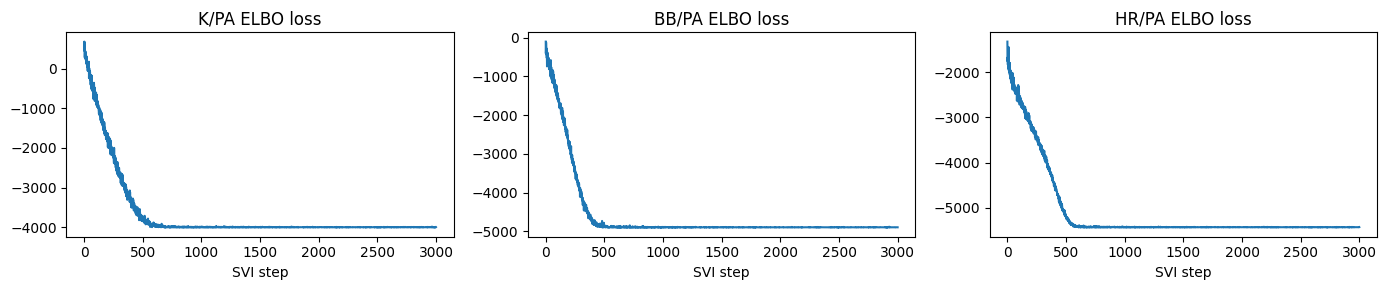

In [41]:
# ── Train All Three Models ─────────────────────────────────────────
# All three guides share the global param store with distinct name prefixes,
# so we never clear the store between models — no params are overwritten.

pyro.clear_param_store()

model_k  = partial(beta_reg_model, name='k')
model_bb = partial(beta_reg_model, name='bb')
model_hr = partial(beta_reg_model, name='hr')

guide_k  = autoguide.AutoNormal(model_k)
guide_bb = autoguide.AutoNormal(model_bb)
guide_hr = autoguide.AutoNormal(model_hr)

print('=== K/PA model (whiff%, chase%) ===')
losses_k  = run_svi(model_k,  guide_k,  X_k_trn,  y_k_trn,  'K',  num_steps=3000)

print('\n=== BB/PA model (chase%) ===')
losses_bb = run_svi(model_bb, guide_bb, X_bb_trn, y_bb_trn, 'BB', num_steps=3000)

print('\n=== HR/PA model (hard_hit%, sweet_spot%) ===')
losses_hr = run_svi(model_hr, guide_hr, X_hr_trn, y_hr_trn, 'HR', num_steps=3000)

# Quick convergence plot
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, losses, label in zip(axes, [losses_k, losses_bb, losses_hr], ['K', 'BB', 'HR']):
    ax.plot(losses)
    ax.set_title(f'{label}/PA ELBO loss')
    ax.set_xlabel('SVI step')
plt.tight_layout()
plt.show()

=== 2025 test-set evaluation ===
  K/PA    MAE=0.0256  Pearson r=0.868  Spearman rho=0.860
  BB/PA   MAE=0.0163  Pearson r=0.722  Spearman rho=0.730
  HR/PA   MAE=0.0116  Pearson r=0.602  Spearman rho=0.599


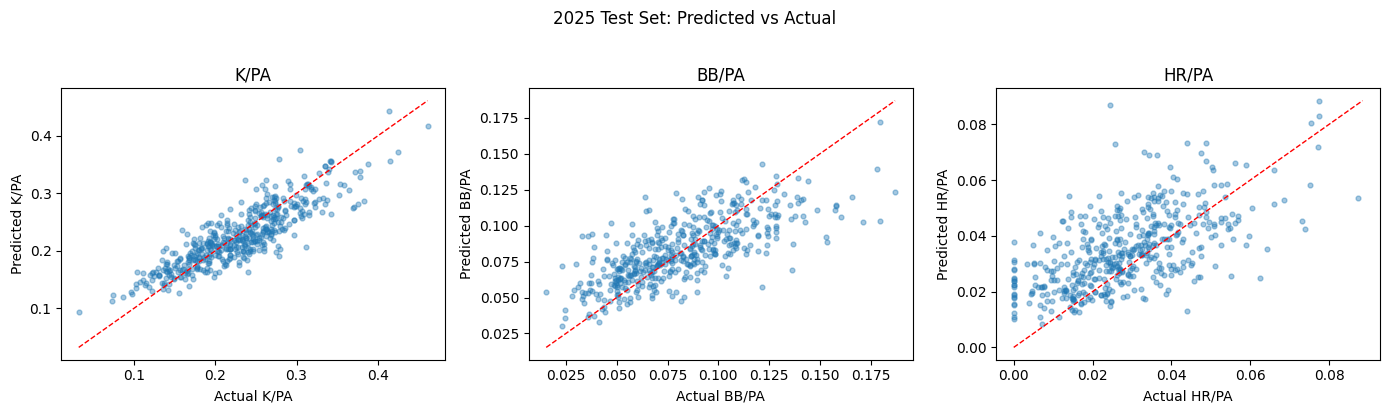

In [42]:
# ── Test-Set Evaluation (2025) ────────────────────────────────────
N_SAMPLES = 2000

mu_k_tst  = posterior_mu_samples(model_k,  guide_k,  X_k_tst,  'k',  N_SAMPLES)
mu_bb_tst = posterior_mu_samples(model_bb, guide_bb, X_bb_tst, 'bb', N_SAMPLES)
mu_hr_tst = posterior_mu_samples(model_hr, guide_hr, X_hr_tst, 'hr', N_SAMPLES)

# Posterior mean predictions vs actuals
from scipy.stats import pearsonr, spearmanr

def eval_model(mu_samples, y_actual, label):
    pred = mu_samples.mean(axis=0)
    act  = y_actual.cpu().numpy()
    mae  = np.abs(pred - act).mean()
    r, _ = pearsonr(pred, act)
    rho, _ = spearmanr(pred, act)
    print(f'  {label:6s}  MAE={mae:.4f}  Pearson r={r:.3f}  Spearman rho={rho:.3f}')
    return pred, act

print('=== 2025 test-set evaluation ===')
pred_k,  act_k  = eval_model(mu_k_tst,  y_k_tst,  'K/PA')
pred_bb, act_bb = eval_model(mu_bb_tst, y_bb_tst, 'BB/PA')
pred_hr, act_hr = eval_model(mu_hr_tst, y_hr_tst, 'HR/PA')

# Scatter plots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, pred, act, label in zip(
        axes,
        [pred_k, pred_bb, pred_hr],
        [act_k,  act_bb,  act_hr],
        ['K/PA', 'BB/PA', 'HR/PA']):
    ax.scatter(act, pred, alpha=0.4, s=12)
    lo, hi = min(act.min(), pred.min()), max(act.max(), pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1)
    ax.set_xlabel(f'Actual {label}')
    ax.set_ylabel(f'Predicted {label}')
    ax.set_title(label)
plt.suptitle('2025 Test Set: Predicted vs Actual', y=1.02)
plt.tight_layout()
plt.show()

In [43]:
# ── 2026 Predictions & Net Power Score ───────────────────────────
# NPS per PA (additive, grounded in scoring system):
#   NPS = HR/PA * W_HR  +  BB/PA * W_BB  −  K/PA * W_K
#
# W_HR = 4.94  (HR=3 + R=0.75 + avg RBI=1.19, from 2021-25 statcast: 1.582 RBI/HR)
# W_BB = 1.23  (BB=1.0 + expected R from runner scoring ≈ 0.23)
# W_K  = 0.50  (direct scoring penalty only)
#
# Uncertainty propagated jointly across all three posterior distributions.
# risk_adj = mean(NPS) − RISK_ALPHA * std(NPS)

N_SAMPLES = 2000

mu_k_pred  = posterior_mu_samples(model_k,  guide_k,  X_k_pred,  'k',  N_SAMPLES)
mu_bb_pred = posterior_mu_samples(model_bb, guide_bb, X_bb_pred, 'bb', N_SAMPLES)
mu_hr_pred = posterior_mu_samples(model_hr, guide_hr, X_hr_pred, 'hr', N_SAMPLES)

nps_samples = mu_hr_pred * W_HR + mu_bb_pred * W_BB - mu_k_pred * W_K
nps_mean    = nps_samples.mean(axis=0)
nps_std     = nps_samples.std(axis=0)
nps_risk    = nps_mean - RISK_ALPHA * nps_std

results = pred_df_shrunk[['batter', 'name', 'PA',
                           'whiff_pct', 'chase_pct', 'hard_hit_pct', 'sweet_spot_pct']].copy()

results['pred_k_per_pa']  = mu_k_pred.mean(axis=0)
results['pred_bb_per_pa'] = mu_bb_pred.mean(axis=0)
results['pred_hr_per_pa'] = mu_hr_pred.mean(axis=0)
results['nps_mean']       = nps_mean
results['nps_risk_adj']   = nps_risk

results = results.sort_values('nps_risk_adj', ascending=False).reset_index(drop=True)
results.index += 1

os.makedirs(os.path.join(os.path.dirname(os.path.abspath('')), 'waiver-tools', 'outputs'), exist_ok=True)
out_path = os.path.join(os.path.dirname(os.path.abspath('')), 'waiver-tools', 'outputs', 'net_power_score_2026.csv')
results.to_csv(out_path, index=True, index_label='rank')
print(f'Saved: {out_path}')
print(f'Players ranked: {len(results)}')

Saved: /Users/mingsenwang/Library/Mobile Documents/com~apple~CloudDocs/data-science/fantasy/dugout-prophet/waiver-tools/outputs/net_power_score_2026.csv
Players ranked: 133


In [44]:
# ── Display Top Rankings ──────────────────────────────────────────
display_cols = ['batter', 'name', 'PA',
                'whiff_pct', 'chase_pct', 'hard_hit_pct', 'sweet_spot_pct',
                'pred_k_per_pa', 'pred_bb_per_pa', 'pred_hr_per_pa',
                'nps_mean', 'nps_risk_adj']

top50 = results[display_cols].head(50).copy()
top50.style.format({
    'whiff_pct':      '{:.1%}',
    'chase_pct':      '{:.1%}',
    'hard_hit_pct':   '{:.1%}',
    'sweet_spot_pct': '{:.1%}',
    'pred_k_per_pa':  '{:.3f}',
    'pred_bb_per_pa': '{:.3f}',
    'pred_hr_per_pa': '{:.3f}',
    'nps_mean':       '{:.4f}',
    'nps_risk_adj':   '{:.4f}',
})

,batter,name,PA,whiff_pct,chase_pct,hard_hit_pct,sweet_spot_pct,pred_k_per_pa,pred_bb_per_pa,pred_hr_per_pa,nps_mean,nps_risk_adj
1,592450,Aaron Judge,21,30.4%,22.4%,59.3%,37.5%,0.303,0.106,0.085,0.4007,0.3939
2,608324,Alex Bregman,23,11.4%,12.7%,45.3%,34.8%,0.152,0.161,0.043,0.3313,0.3290
3,650490,Yandy Díaz,25,12.0%,24.7%,52.3%,28.4%,0.142,0.096,0.056,0.3216,0.3178
4,665487,Fernando Tatís,20,25.6%,27.0%,55.2%,33.5%,0.245,0.086,0.067,0.3171,0.3128
5,670541,Yordan Álvarez,28,16.0%,32.8%,53.1%,37.1%,0.158,0.066,0.064,0.3166,0.3125
6,660271,Shohei Ohtani,22,20.4%,26.3%,52.1%,35.3%,0.200,0.089,0.059,0.3030,0.2995
7,608369,Corey Seager,24,26.1%,24.8%,52.7%,38.2%,0.253,0.095,0.063,0.3014,0.2971
8,607043,Brandon Nimmo,24,17.8%,20.6%,48.4%,34.0%,0.188,0.115,0.049,0.2889,0.2864
9,572233,Christian Walker,24,25.3%,25.4%,51.2%,38.5%,0.245,0.093,0.059,0.2819,0.2781
10,518692,Freddie Freeman,21,16.0%,24.9%,45.6%,45.3%,0.168,0.095,0.048,0.2718,0.2672


In [45]:
# ── Re-rank with Custom Alpha ─────────────────────────────────────
# Adjust alpha without retraining. W_HR / W_BB / W_K are set in the config cell.
# alpha = 0   → pure expected NPS
# alpha = 0.5 → moderate risk penalty (default)
# alpha = 1.0 → conservative

CUSTOM_ALPHA = 0.5

results['nps_risk_adj'] = results['nps_mean'] - CUSTOM_ALPHA * nps_std
results = results.sort_values('nps_risk_adj', ascending=False).reset_index(drop=True)
results.index += 1

results[['batter', 'name', 'PA', 'pred_hr_per_pa', 'pred_bb_per_pa', 'pred_k_per_pa',
         'nps_mean', 'nps_risk_adj']].head(80).style.format({
    'pred_hr_per_pa': '{:.3f}',
    'pred_bb_per_pa': '{:.3f}',
    'pred_k_per_pa':  '{:.3f}',
    'nps_mean':       '{:.4f}',
    'nps_risk_adj':   '{:.4f}',
})

,batter,name,PA,pred_hr_per_pa,pred_bb_per_pa,pred_k_per_pa,nps_mean,nps_risk_adj
1,592450,Aaron Judge,21,0.085,0.106,0.303,0.4007,0.3995
2,608324,Alex Bregman,23,0.043,0.161,0.152,0.3313,0.3267
3,650490,Yandy Díaz,25,0.056,0.096,0.142,0.3216,0.3187
4,665487,Fernando Tatís,20,0.067,0.086,0.245,0.3171,0.3162
5,670541,Yordan Álvarez,28,0.064,0.066,0.158,0.3166,0.3148
6,608369,Corey Seager,24,0.063,0.095,0.253,0.3014,0.3001
7,660271,Shohei Ohtani,22,0.059,0.089,0.200,0.3030,0.3000
8,607043,Brandon Nimmo,24,0.049,0.115,0.188,0.2889,0.2869
9,572233,Christian Walker,24,0.059,0.093,0.245,0.2819,0.2781
10,518692,Freddie Freeman,21,0.048,0.095,0.168,0.2718,0.2703
